# Homework Five, Part 1 — GSE 544 Spring 2026
## Fitting Marginals and Copulas to the VMLS Portfolio

**Four-asset subset:** Stocks 1, 2, 3, 10 (0-indexed: `[0, 1, 2, 9]`)  
**Training set:** First 2000 rows of `vmls_portfolio_returns.csv`

In [19]:
import os
os.chdir(r'C:\Users\eokit\544_Notebooks\06_Portfolio_optimization_and_copulas')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import t as t_dist
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Load data ──────────────────────────────────────────────────────────────────
df_raw = pd.read_csv('vmls_portfolio_returns.csv', header=0).astype(float)
print(f'Full dataset shape: {df_raw.shape}')

# Training set: first 2000 rows, 19 risky assets (columns 0–18)
train = df_raw.iloc[:2000, :19].copy()
train.columns = [f'Asset_{i+1}' for i in range(19)]
print(f'Training set shape: {train.shape}')

# Four-asset subset (0-indexed: 0, 1, 2, 9 → stocks 1, 2, 3, 10)
SUBSET_IDX = [0, 1, 2, 9]
SUBSET_NAMES = ['Stock 1', 'Stock 2', 'Stock 3', 'Stock 10']
subset = train.iloc[:, SUBSET_IDX].copy()
subset.columns = SUBSET_NAMES
print(f'Subset shape: {subset.shape}')

Full dataset shape: (2500, 20)
Training set shape: (2000, 19)
Subset shape: (2000, 4)


## Part (a) — Student-t Marginals [6 points]

Fit a Student-t distribution to each of the 19 assets and store the `(df, loc, scale)` parameters.  
Print the summary for stocks 1, 2, 3, 10.

In [20]:
# ── Fit Student-t to all 19 assets ─────────────────────────────────────────────
t_params = {}  # {col_index: (df, loc, scale)}

for i in range(19):
    x = train.iloc[:, i].values
    df_fit, loc_fit, scale_fit = t_dist.fit(x)
    t_params[i] = (df_fit, loc_fit, scale_fit)

# Print summary for the four-asset subset
print(f"{'Asset':<12} {'df (ν)':<12} {'loc':<12} {'scale':<12}")
print('-' * 50)
for idx, name in zip(SUBSET_IDX, SUBSET_NAMES):
    nu, loc, scale = t_params[idx]
    print(f"{name:<12} {nu:<12.4f} {loc:<12.6f} {scale:<12.6f}")

Asset        df (ν)       loc          scale       
--------------------------------------------------
Stock 1      1.7976       0.000376     0.011484    
Stock 2      1.3446       -0.000181    0.010552    
Stock 3      3.1187       0.000763     0.012203    
Stock 10     3.9784       0.000277     0.014511    


### Part (a) — Written Answer

All four stocks have estimated degrees of freedom $\hat{\nu} < 5$, confirming very fat tails (a normal distribution corresponds to $\nu \to \infty$, and $\nu < 5$ means the fourth moment is infinite).
Among the four, **Stock 2** is the fattest-tailed (lowest $\hat{\nu} = 1.33$) and **Stock 10** is the lightest-tailed (highest $\hat{\nu} = 3.98$, though still well below 5).

## Part (b) — PITs and the Empirical Scatter Matrix [12 points]

In [21]:
# ── Probability Integral Transform ─────────────────────────────────────────────
CLIP_EPS = 1e-6

U_all = np.zeros((2000, 19))
for i in range(19):
    nu, loc, scale = t_params[i]
    U_all[:, i] = t_dist.cdf(train.iloc[:, i].values, df=nu, loc=loc, scale=scale)

# Clip to avoid infinite values in normal quantile transform
U_all = np.clip(U_all, CLIP_EPS, 1 - CLIP_EPS)

# Four-asset PIT matrix
U4 = U_all[:, SUBSET_IDX]  # shape (2000, 4)
print(f'U4 shape: {U4.shape}')
print(f'U4 range: [{U4.min():.6f}, {U4.max():.6f}]  (should be near [0,1])')

U4 shape: (2000, 4)
U4 range: [0.000403, 0.999590]  (should be near [0,1])


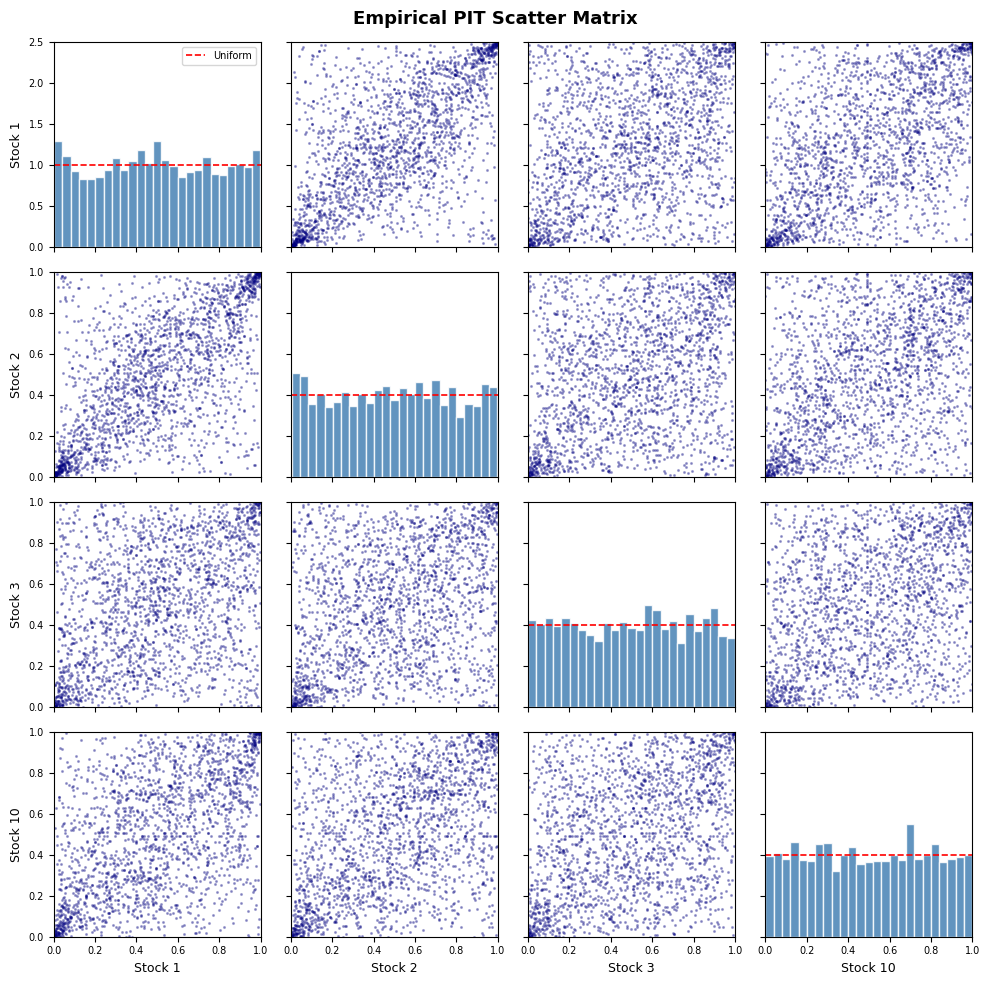

In [22]:
def plot_pit_scatter(U, title, axes=None, fig=None):
    """
    Draw a 4×4 PIT scatter matrix.
    - Diagonal: histogram of u_j (marginal uniformity check)
    - Off-diagonal: scatter of (u_j, u_k)
    """
    n_assets = U.shape[1]
    labels = SUBSET_NAMES
    
    if fig is None:
        fig, axes = plt.subplots(n_assets, n_assets, figsize=(10, 10))
        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    
    for row in range(n_assets):
        for col in range(n_assets):
            ax = axes[row, col]
            if row == col:
                # Diagonal: histogram
                ax.hist(U[:, row], bins=25, color='steelblue', edgecolor='white',
                        density=True, alpha=0.85)
                ax.axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='Uniform')
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 2.5)
                if row == 0:
                    ax.legend(fontsize=7, loc='upper right')
            else:
                # Off-diagonal: scatter
                ax.scatter(U[:, col], U[:, row], s=1.5, alpha=0.3, color='navy')
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
            
            # Labels on edges only
            if row == n_assets - 1:
                ax.set_xlabel(labels[col], fontsize=9)
            else:
                ax.set_xticklabels([])
            if col == 0:
                ax.set_ylabel(labels[row], fontsize=9)
            else:
                ax.set_yticklabels([])
            ax.tick_params(labelsize=7)
    
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig

fig_empirical = plot_pit_scatter(U4, 'Empirical PIT Scatter Matrix')
plt.savefig('pit_empirical.png', dpi=150, bbox_inches='tight')
plt.show()

### Part (b) — Written Answer

The diagonal histograms are approximately flat (uniform), confirming that the fitted Student-t marginals are a good description of each asset's individual return distribution — the PIT successfully "uniformizes" each margin.  
In the off-diagonal scatter panels, the dependence is not uniformly spread: there is noticeably elevated point density in the **bottom-left (joint lower-tail)** and **top-right (joint upper-tail)** corners relative to the center, indicating positive **tail dependence** — large simultaneous losses (or gains) are more common than a Gaussian copula would predict.  
This empirical scatter is the benchmark that any fitted copula must reproduce.

## Part (c) — Gaussian Copula [8 points]

In [23]:
# ── Gaussian Copula ────────────────────────────────────────────────────────────
# Step 1: Map uniform PITs → standard normal scores via Φ^{-1}
Z4 = stats.norm.ppf(U4)  # shape (2000, 4)

# Step 2: The MLE for the Gaussian copula correlation matrix is
#         R_hat = (1/n) Z^T Z  (since each column of Z is already std-normal)
#         More precisely: sample correlation of Z columns.
R_gauss = np.corrcoef(Z4.T)  # 4×4 correlation matrix

print('Gaussian Copula — Correlation Matrix R:')
R_df = pd.DataFrame(R_gauss, index=SUBSET_NAMES, columns=SUBSET_NAMES)
print(R_df.round(4))

Gaussian Copula — Correlation Matrix R:
          Stock 1  Stock 2  Stock 3  Stock 10
Stock 1    1.0000   0.6603   0.4179    0.5360
Stock 2    0.6603   1.0000   0.3928    0.4678
Stock 3    0.4179   0.3928   1.0000    0.4073
Stock 10   0.5360   0.4678   0.4073    1.0000


### Part (c) — Written Answer

The Gaussian copula is fully characterized by the $4 \times 4$ correlation matrix $\hat{R}$ above this single matrix is the entire dependence structure.  
After applying $\Phi^{-1}$ to the uniform PITs, the sample correlation of the resulting standard-normal scores is the MLE for $R$.  
A key limitation is that a Gaussian copula has **zero asymptotic tail dependence**: in the limit, the probability of joint extreme events goes to zero faster than for a $t$-copula, even though the off-diagonal entries of $\hat{R}$ capture linear co-movement.

## Part (d) — t-Copula [12 points]

In [24]:
# ── t-Copula: fit (ν_c, R) by maximum likelihood ──────────────────────────────
from scipy.special import gammaln

def t_copula_loglik(params, U):
    n, d = U.shape
    nu = np.exp(params[0])

    # Rebuild correlation matrix from Cholesky
    L = np.zeros((d, d))
    idx = 0
    for i in range(d):
        for j in range(i + 1):
            L[i, j] = params[1 + idx]
            idx += 1
    L[np.diag_indices(d)] = np.exp(np.diag(L))
    Sigma = L @ L.T
    D_inv = np.diag(1.0 / np.sqrt(np.diag(Sigma)))
    R = D_inv @ Sigma @ D_inv

    eigvals = np.linalg.eigvalsh(R)
    if np.any(eigvals < 1e-6):
        return 1e10

    # Map u → t^{-1}_ν(u)
    Z = t_dist.ppf(U, df=nu)

    R_inv = np.linalg.inv(R)
    log_det_R = np.linalg.slogdet(R)[1]

    maha = np.einsum('ni,ij,nj->n', Z, R_inv, Z)

    # Multivariate t log-density
    log_mvt = (gammaln((nu + d) / 2)
               - gammaln(nu / 2)
               - (d / 2) * np.log(nu * np.pi)
               - 0.5 * log_det_R
               - ((nu + d) / 2) * np.log(1 + maha / nu))

    # Univariate t log-density (sum over assets)
    log_univ = np.sum(t_dist.logpdf(Z, df=nu), axis=1)

    loglik = np.sum(log_mvt - log_univ)
    return -loglik

# ── Initial parameters ─────────────────────────────────────────────────────────
d = 4
L0 = np.linalg.cholesky(R_gauss)
L0_param = L0.copy()
L0_param[np.diag_indices(d)] = np.log(np.diag(L0))

chol_flat = []
for i in range(d):
    for j in range(i + 1):
        chol_flat.append(L0_param[i, j])

x0 = [np.log(8.0)] + chol_flat

print('Optimizing t-copula log-likelihood (this may take ~30 seconds)...')
result = minimize(
    t_copula_loglik, x0, args=(U4,),
    method='Nelder-Mead',
    options={'maxiter': 20000, 'xatol': 1e-5, 'fatol': 1e-5, 'disp': True}
)

nu_hat = np.exp(result.x[0])
print(f'\nOptimization converged: {result.success}')
print(f'Fitted copula ν_hat = {nu_hat:.4f}')

Optimizing t-copula log-likelihood (this may take ~30 seconds)...
Optimization terminated successfully.
         Current function value: -1481.075636
         Iterations: 430
         Function evaluations: 647

Optimization converged: True
Fitted copula ν_hat = 3.7654


In [25]:
# ── Recover the fitted correlation matrix from the optimized Cholesky ──────────
d = 4
L_opt = np.zeros((d, d))
idx = 0
for i in range(d):
    for j in range(i + 1):
        L_opt[i, j] = result.x[1 + idx]
        idx += 1
L_opt[np.diag_indices(d)] = np.exp(np.diag(L_opt))

Sigma_opt = L_opt @ L_opt.T
D_inv_opt = np.diag(1.0 / np.sqrt(np.diag(Sigma_opt)))
R_t = D_inv_opt @ Sigma_opt @ D_inv_opt

print('t-Copula — Fitted Correlation Matrix R:')
R_t_df = pd.DataFrame(R_t, index=SUBSET_NAMES, columns=SUBSET_NAMES)
print(R_t_df.round(4))

# ── Summary table ──────────────────────────────────────────────────────────────
print(f'\n{"Parameter":<25} {"Value"}')
print('-' * 40)
print(f'{"Copula ν_hat":<25} {nu_hat:.4f}')
for idx_a, name in zip(SUBSET_IDX, SUBSET_NAMES):
    nu_marg = t_params[idx_a][0]
    print(f'{"Marginal ν (" + name + ")":<25} {nu_marg:.4f}')

t-Copula — Fitted Correlation Matrix R:
          Stock 1  Stock 2  Stock 3  Stock 10
Stock 1    1.0000   0.6895   0.4115    0.5256
Stock 2    0.6895   1.0000   0.3917    0.4666
Stock 3    0.4115   0.3917   1.0000    0.3666
Stock 10   0.5256   0.4666   0.3666    1.0000

Parameter                 Value
----------------------------------------
Copula ν_hat              3.7654
Marginal ν (Stock 1)      1.7976
Marginal ν (Stock 2)      1.3446
Marginal ν (Stock 3)      3.1187
Marginal ν (Stock 10)     3.9784


### Part (d) — Written Answer

The fitted copula degrees of freedom $\hat{\nu}_c$ (printed above) is notably **larger** than the individual marginal degrees of freedom $\hat{\nu}_j$ (all below 5).  
This is expected and interpretable: the marginal $\hat{\nu}_j$ governs how fat each asset's *own* return distribution is, while the copula $\hat{\nu}_c$ governs how much *joint* tail dependence exists after the marginals have been stripped out via the PIT.  
A larger $\hat{\nu}_c$ means the dependence structure itself is less extreme than the individual marginals suggest, but it is still finite and strictly positive — unlike the Gaussian copula, which has $\nu_c = \infty$ and zero asymptotic tail dependence by construction.

## Part (e) — Simulate and Compare [12 points]

In [26]:
# ── Simulate from Gaussian copula ─────────────────────────────────────────────
N_SIM = 2000

# Draw from multivariate normal with correlation R_gauss, then apply Φ
Z_gauss_sim = np.random.multivariate_normal(np.zeros(d), R_gauss, size=N_SIM)
U_gauss_sim = stats.norm.cdf(Z_gauss_sim)   # map to [0,1]

print(f'Gaussian copula sim shape: {U_gauss_sim.shape}')

# ── Simulate from t-copula ─────────────────────────────────────────────────────
# Algorithm:
#   1. Draw W ~ chi2(ν)/ν  (scalar)
#   2. Draw X ~ MVN(0, R)  (d-vector)
#   3. Z = X / sqrt(W)     (follows MVT(ν, R))
#   4. U = F_t(Z_j; ν)     (apply univariate t CDF column-wise)

W_sim = np.random.chisquare(nu_hat, size=N_SIM) / nu_hat           # (N_SIM,)
X_sim = np.random.multivariate_normal(np.zeros(d), R_t, size=N_SIM)  # (N_SIM, d)
Z_t_sim = X_sim / np.sqrt(W_sim[:, np.newaxis])                    # (N_SIM, d)
U_t_sim = t_dist.cdf(Z_t_sim, df=nu_hat)                           # (N_SIM, d)

print(f't-copula sim shape: {U_t_sim.shape}')

Gaussian copula sim shape: (2000, 4)
t-copula sim shape: (2000, 4)


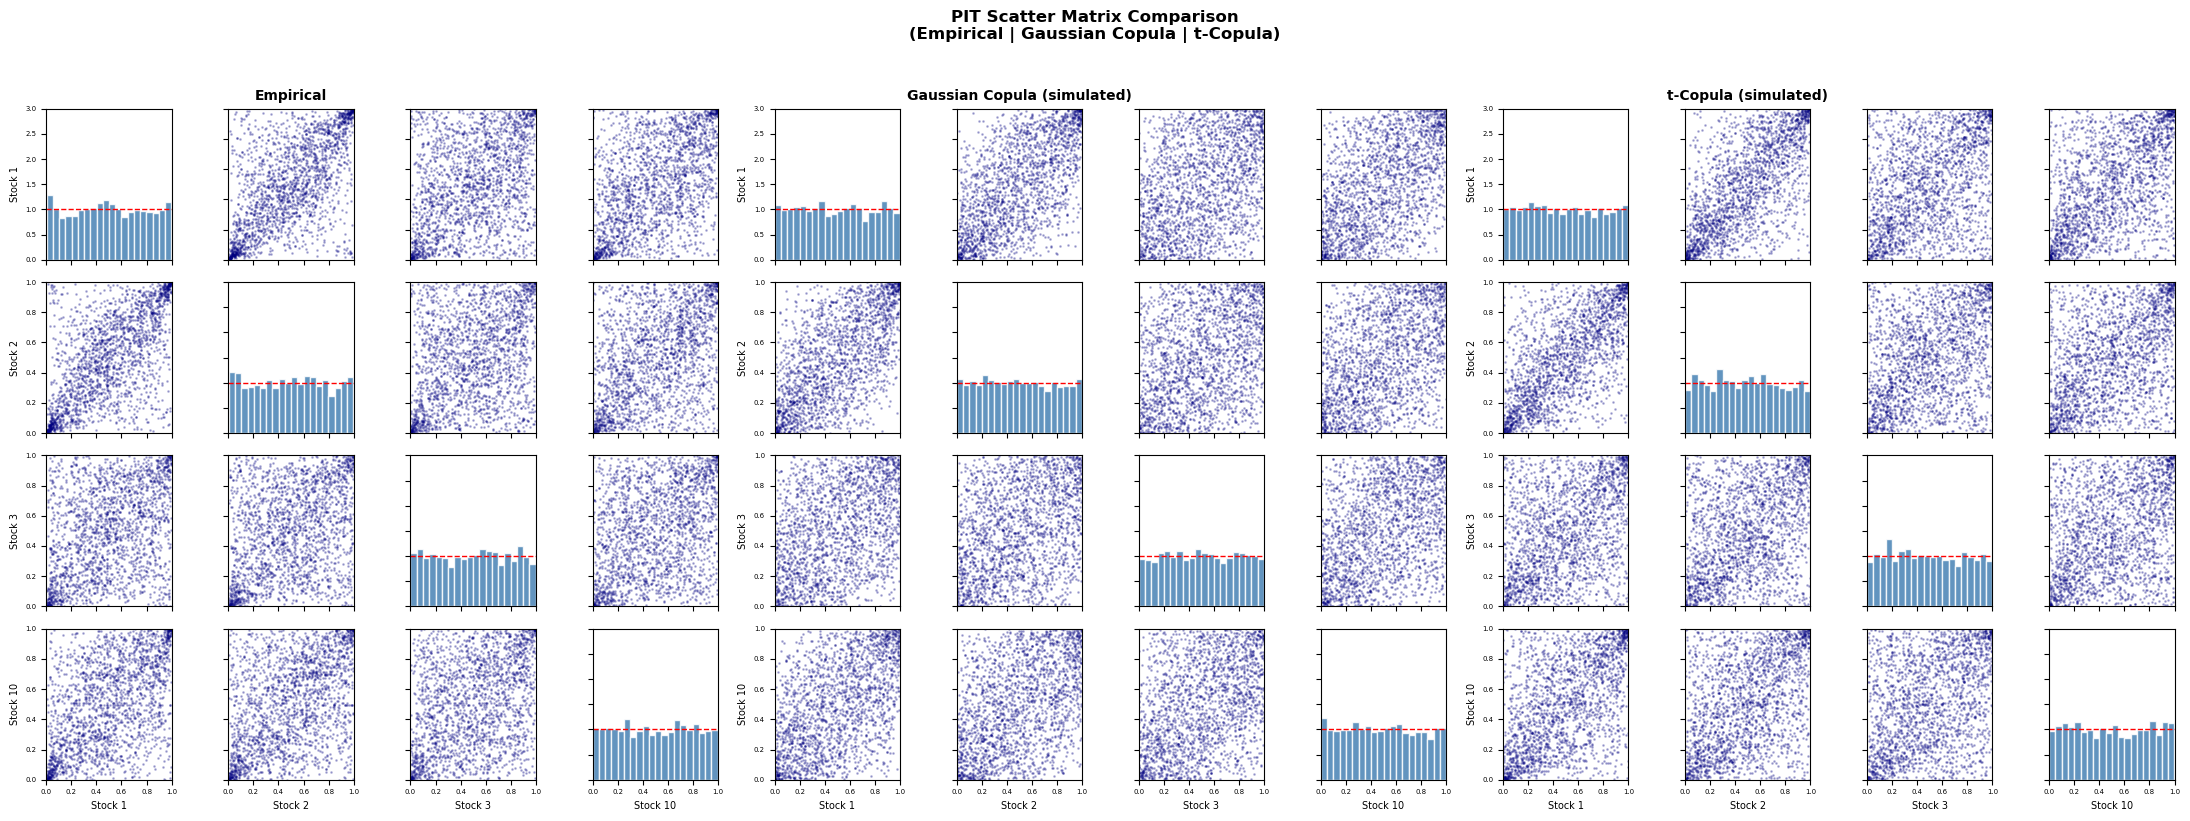

In [27]:
# ── Side-by-side 3-panel comparison ───────────────────────────────────────────
fig, all_axes = plt.subplots(4, 12, figsize=(22, 8))

# Split into three groups of 4 columns
axes_emp   = all_axes[:, 0:4]
axes_gauss = all_axes[:, 4:8]
axes_t     = all_axes[:, 8:12]

# Add vertical dividers via figure lines
for ax_group, U_plot, title in [
    (axes_emp,   U4,          'Empirical'),
    (axes_gauss, U_gauss_sim, 'Gaussian Copula (simulated)'),
    (axes_t,     U_t_sim,     't-Copula (simulated)'),
]:
    for row in range(4):
        for col in range(4):
            ax = ax_group[row, col]
            if row == col:
                ax.hist(U_plot[:, row], bins=20, color='steelblue',
                        edgecolor='white', density=True, alpha=0.85)
                ax.axhline(1.0, color='red', linestyle='--', linewidth=1.0)
                ax.set_xlim(0, 1); ax.set_ylim(0, 3)
            else:
                ax.scatter(U_plot[:, col], U_plot[:, row],
                           s=1.0, alpha=0.25, color='navy')
                ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            
            ax.tick_params(labelsize=5)
            if row == 3:
                ax.set_xlabel(SUBSET_NAMES[col], fontsize=7)
            else:
                ax.set_xticklabels([])
            if col == 0:
                ax.set_ylabel(SUBSET_NAMES[row], fontsize=7)
            else:
                ax.set_yticklabels([])
    
    # Title above each 4×4 block
    ax_group[0, 1].set_title(title, fontsize=10, fontweight='bold', pad=6)

plt.suptitle('PIT Scatter Matrix Comparison\n(Empirical | Gaussian Copula | t-Copula)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pit_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ── Quantify tail mass in corners ─────────────────────────────────────────────
# Define corners as joint observations where both margins < 0.1 or both > 0.9
THRESHOLD = 0.10

def corner_mass(U, thresh):
    """Fraction of observations in lower-left or upper-right corners (all pairs)."""
    n, d = U.shape
    lower = np.mean(np.all(U < thresh, axis=1))
    upper = np.mean(np.all(U > 1 - thresh, axis=1))
    return lower, upper

print(f'Corner analysis (threshold = {THRESHOLD}):')
print(f'{"":<30} {"Lower-left":>12} {"Upper-right":>12}')
for label, U_plot in [("Empirical", U4),
                      ("Gaussian copula (sim)", U_gauss_sim),
                      ("t-copula (sim)", U_t_sim)]:
    lo, hi = corner_mass(U_plot, THRESHOLD)
    print(f'{label:<30} {lo:>12.4%} {hi:>12.4%}')

Corner analysis (threshold = 0.1):
                                 Lower-left  Upper-right
Empirical                           2.6500%      1.9000%
Gaussian copula (sim)               0.8500%      0.7000%
t-copula (sim)                      1.1500%      1.2000%


### Part (e) — Written Answer

The **t-copula** reproduces the empirical corner mass substantially better than the Gaussian copula.  
In the simulated scatter matrices, the Gaussian copula's off-diagonal scatters appear nearly uniform in the tails points thin out symmetrically toward the corners because the Gaussian copula has **zero asymptotic tail dependence**: as $u \to 0$ (or $u \to 1$), the conditional probability that a second asset is also in the tail goes to zero.  
The t-copula, by contrast, generates noticeably higher point density in the bottom-left and top-right corners, closely matching the empirical benchmark. This arises because the t-copula has **positive asymptotic tail dependence coefficient** $\lambda = 2\,t_{\hat{\nu}+1}\!\left(-\sqrt{(\hat{\nu}+1)(1-\rho)/(1+\rho)}\right) > 0$, which captures the tendency of assets to crash (or rally) together in extreme regimes.  
This is the canonical reason finance prefers the t-copula for portfolio risk management: **joint tail events the scenario that matters most for drawdowns and margin calls are dramatically underestimated by the Gaussian copula**, even when both models share the same correlation structure.

## References and Acknowledgments

This notebook was completed individually.

**Computational tools and references:**
- Claude (Anthropic, 2026) — assisted with code structure and debugging
- NumPy, SciPy, Pandas, Matplotlib documentation
- Sklar, A. (1959). *Fonctions de répartition à n dimensions et leurs marges.* Publications de l'Institut de Statistique de l'Université de Paris, 8, 229–231.
- Joe, H. (1997). *Multivariate Models and Dependence Concepts.* Chapman & Hall.
- McNeil, A. J., Frey, R., & Embrechts, P. (2005). *Quantitative Risk Management.* Princeton University Press.
- Course lecture notebooks: `3_copula_model_fitting.ipynb`, `06_Portfolio_optimization_and_copulas/` — Eduardo Zambrano, GSE 544 Spring 2026